<a href="https://colab.research.google.com/github/joehiggi/graph-theoretic-applications-in-insurance-risk-management/blob/main/src/GTAIRM_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Theoretic Applications in Insurance Risk Management


## 1. Data source

We use **EDGAR-CORPUS** — a peer-reviewed corpus of the full text of every SEC 10-K annual report from 1993–2020, segmented into the standard items (Item 1A Risk Factors, Item 7 MD&A, …).

> Loukas, Fergadiotis, Chalkidis, Spyropoulou, Malakasiotis, Androutsopoulos & Paliouras (2021). *EDGAR-CORPUS: Billions of Tokens Make The World Go Round.* Proceedings of the Third Workshop on Economics and Natural Language Processing (ECONLP @ EMNLP 2021). [arXiv:2109.14394](https://arxiv.org/abs/2109.14394)

Hosted on the Hugging Face Hub at [`eloukas/edgar-corpus`](https://huggingface.co/datasets/eloukas/edgar-corpus).

**Loading approach — stream, don't store.** Hugging Face removed script-based datasets, so the old `load_dataset("eloukas/edgar-corpus", "full")` call no longer works. Instead we read directly from the Hub's auto-generated **parquet** mirror with `streaming=True`. Rows arrive on demand over HTTP and nothing is written to local disk — ideal for a laptop or a fresh Colab runtime.

Each record has: `filename`, `cik` (the SEC company id), `year`, and `section_1` … `section_15` (the 10-K items, with `section_1A` = Risk Factors and `section_7` = MD&A).

In [1]:
%pip install -q datasets huggingface_hub pyarrow scikit-learn networkx pandas matplotlib

In [3]:
import itertools

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 2. Stream a slice of 10-K filings

We point the generic `parquet` loader at the Hub's parquet branch (`refs/convert/parquet`) for a single filing year. `streaming=True` returns an iterable that fetches rows lazily — we take the first `n_filings` that actually contain a Risk Factors section.

Pick any `YEAR` between 1993 and 2020. Risk-factor disclosure (Item 1A) became mandatory in 2005, so 2010+ gives the richest text.

In [4]:
YEAR = 2018          # any year in 1993-2020
N_FILINGS = 300      # how many filings to pull into the graph

# The Hub auto-converts the script dataset to parquet on this branch; we read it directly.
parquet_glob = (
    f"hf://datasets/eloukas/edgar-corpus@refs/convert/parquet/"
    f"year_{YEAR}/train/*.parquet"
)

stream = load_dataset(
    "parquet",
    data_files=parquet_glob,
    split="train",
    streaming=True,        # nothing is stored locally
)


def has_risk_factors(record, min_chars=500):
    """Keep filings with a substantive Item 1A (Risk Factors) section."""
    text = record.get("section_1A") or ""
    return len(text) >= min_chars


records = list(
    itertools.islice((r for r in stream if has_risk_factors(r)), N_FILINGS)
)

df = pd.DataFrame(records)[["cik", "year", "filename", "section_1A", "section_7"]]
df = df.rename(columns={"section_1A": "risk_factors", "section_7": "mdna"})
print(f"Loaded {len(df)} filings from {YEAR} (streamed, nothing saved to disk).")
df[["cik", "year", "filename"]].head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded 300 filings from 2018 (streamed, nothing saved to disk).


,cik,year,filename
0,1566373,2018,1566373_2018.htm
1,1263364,2018,1263364_2018.htm
2,1431567,2018,1431567_2018.htm
3,1558583,2018,1558583_2018.htm
4,1456857,2018,1456857_2018.htm


## 3. Build the firm-similarity graph

1. Vectorise each firm's Risk Factors text with TF-IDF.
2. Compute pairwise cosine similarity between firms.
3. Add an edge whenever similarity exceeds a threshold; the weight is the similarity.

Edges therefore link firms that frame their risks in similar language — a proxy for shared exposure channels.

In [5]:
SIM_THRESHOLD = 0.30   # minimum cosine similarity to draw an edge

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=3,
)
tfidf = vectorizer.fit_transform(df["risk_factors"])
sim = cosine_similarity(tfidf)

G = nx.Graph()
for idx, row in df.iterrows():
    G.add_node(row["cik"], filename=row["filename"])

ciks = df["cik"].tolist()
for i in range(len(ciks)):
    for j in range(i + 1, len(ciks)):
        w = sim[i, j]
        if w >= SIM_THRESHOLD:
            G.add_edge(ciks[i], ciks[j], weight=float(w))

print(f"Graph: {G.number_of_nodes()} firms, {G.number_of_edges()} edges "
      f"(threshold={SIM_THRESHOLD}).")

Graph: 300 firms, 12834 edges (threshold=0.3).


## 4. An aggregate exposure metric

Network centrality summarises how central a firm's risk profile is within the disclosure network. A firm whose risk language overlaps with many others sits at the centre of a shared-exposure cluster — a candidate *systemic* node.

We report weighted-degree and eigenvector centrality; either can serve as the single-number exposure score the research question asks for.

In [7]:
weighted_degree = dict(G.degree(weight="weight"))
try:
    eigen = nx.eigenvector_centrality_numpy(G, weight="weight")
except Exception:
    eigen = {n: float("nan") for n in G.nodes}

exposure = (
    pd.DataFrame({
        "cik": list(G.nodes),
        "weighted_degree": [weighted_degree[n] for n in G.nodes],
        "eigenvector_centrality": [eigen[n] for n in G.nodes],
    })
    .sort_values("eigenvector_centrality", ascending=False)
    .reset_index(drop=True)
)
exposure.head(10)

,cik,weighted_degree,eigenvector_centrality
0,1566373,30.709366,NaN
1,1263364,0.769585,NaN
2,1431567,64.511451,NaN
3,1558583,47.691671,NaN
4,1456857,6.947324,NaN
5,1046025,20.883036,NaN
6,1493976,23.999848,NaN
7,1308547,16.961559,NaN
8,1610250,32.994105,NaN
9,887226,60.050049,NaN


## 5. Visualise the network

Node size scales with weighted degree, so high-exposure firms stand out. Connected components are clusters of firms sharing a risk vocabulary.

Saved static graph -> /content/data/output/risk_factor_network_2018.png


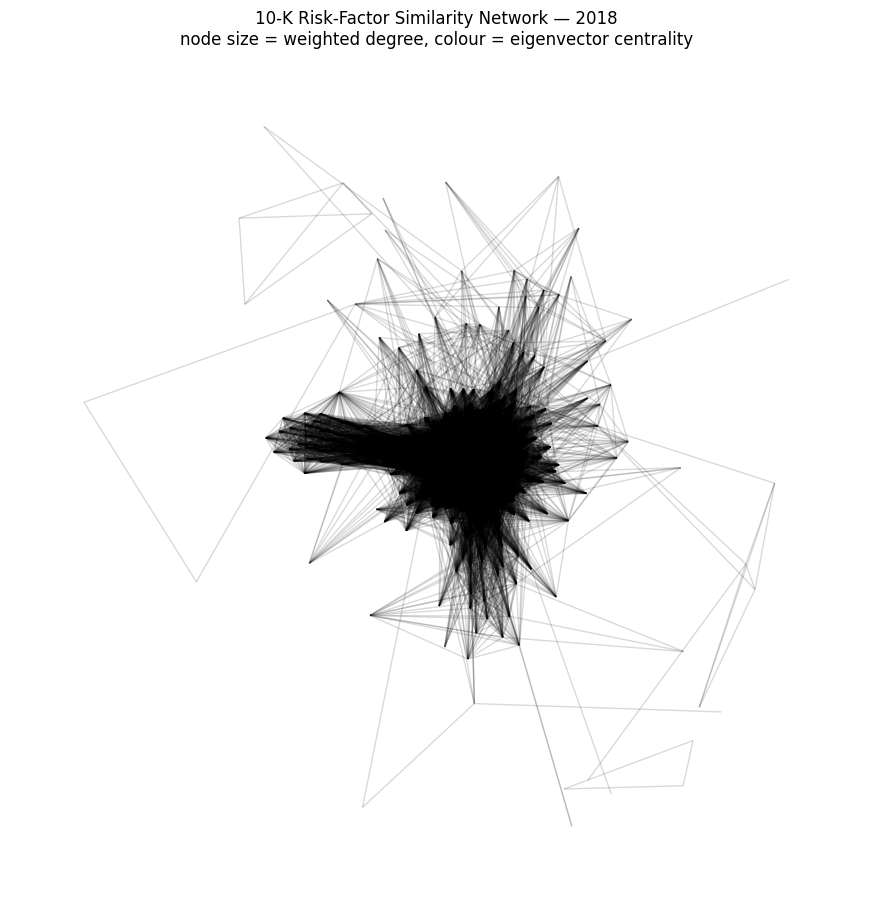

In [8]:
from pathlib import Path

fig, ax = plt.subplots(figsize=(11, 11))
pos = nx.spring_layout(G, seed=42, k=0.3, weight="weight")
sizes = [40 + 120 * weighted_degree[n] for n in G.nodes]

nx.draw_networkx_edges(G, pos, alpha=0.15, ax=ax)
nx.draw_networkx_nodes(
    G, pos,
    node_size=sizes,
    node_color=[eigen[n] for n in G.nodes],
    cmap="viridis",
    ax=ax,
)
ax.set_title(
    f"10-K Risk-Factor Similarity Network — {YEAR}\n"
    f"node size = weighted degree, colour = eigenvector centrality"
)
ax.axis("off")

# Persist the static graph to data/output/ (the notebook lives in src/).
OUTPUT_DIR = Path("../data/output") if Path("../data").exists() else Path("data/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUTPUT_DIR / f"risk_factor_network_{YEAR}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved static graph -> {out_path.resolve()}")

plt.show()

## Where to take this next

- **Sector lens for insurance.** Map `cik` to SIC industry codes (via the SEC company-facts API) and restrict to insurers / financials to study intra-industry contagion.
- **Temporal networks.** Loop over years and track how a firm's centrality (exposure score) evolves through crises (2008, 2020).
- **Other edges.** Swap risk-factor similarity for MD&A (`section_7`) similarity, or use embeddings instead of TF-IDF.
- **Validation.** Correlate centrality with realised outcomes (volatility, downgrades) to test whether the aggregate metric is predictive.

### References
- Loukas et al. (2021), *EDGAR-CORPUS*. [arXiv:2109.14394](https://arxiv.org/abs/2109.14394)
- Dataset: [`eloukas/edgar-corpus`](https://huggingface.co/datasets/eloukas/edgar-corpus)